# Whakaari Cause–Trigger Analysis

This notebook applies the cleaned Cause–Trigger workflow to the fixed case-study interval around the 2019 eruption.

Two aligned frames are used:

- `X_model`: case-standardized data for causal discovery, coefficient estimation, \(V\), and moderation;
- `X_mean`: pre-case-reference-standardized data for the split and mean-comparison steps.

The known event time is shown only as physical context. The split remains data-driven.

## 1. Imports, paths, and case-study interval

In [3]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from cause_trigger_whakaari import (
    COMPACT_RUN_SPECS,
    EFFECT,
    WhakaariWorkflowConfig,
    case_study_interval,
    compact_comparison,
    compact_diagnostics,
    compact_grid_errors,
    compact_sensitivity,
    load_model_frame,
    model_overview,
    plot_effect_with_split,
    pre_case_reference_interval,
    prepare_case_frames,
    reference_parameter_table,
    run_sensitivity_grid,
    run_suite,
    split_diagnostics,
)

DATA_DIR = PROJECT_ROOT / "data" / "whakaari"
WHAKAARI_PATH = DATA_DIR / "whakaari_dataset.csv"
EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")

In [4]:
CASE_PRE_DAYS = 14
CASE_POST_HOURS = 72
MIN_I1_LENGTH = 168
MIN_I2_LENGTH = 48
MAX_LAGS = 6

REFERENCE_DAYS = 14
REFERENCE_MIN_COVERAGE = 0.90
COND_IND_TEST = "robust_parcorr"

MODEL_COLUMNS = [
    "hydro_2_5",
    "spectral_log_ratio_4p5_8_over_8_16",
    "event_rate_2_5",
    "effect_tremor_5_15",
    "rainfall_mm",
    "pressure_drop",
]

X_full_raw = load_model_frame(
    WHAKAARI_PATH,
    include_columns=MODEL_COLUMNS,
    require_complete=False,
)
X_case_raw = case_study_interval(
    X_full_raw,
    EVENT_TIME,
    pre_days=CASE_PRE_DAYS,
    post_hours=CASE_POST_HOURS,
)
reference_raw = pre_case_reference_interval(
    X_full_raw,
    case_start=X_case_raw.index.min(),
    reference_days=REFERENCE_DAYS,
    min_coverage=REFERENCE_MIN_COVERAGE,
)
X_model, X_mean, scaling_report = prepare_case_frames(
    X_case_raw,
    reference_raw,
)

print(
    "Reference coverage: "
    f"{len(reference_raw)}/{reference_raw.attrs['expected_rows']} hourly rows "
    f"({reference_raw.attrs['coverage']:.1%})"
)
display(pd.DataFrame([model_overview(X_model, EFFECT)]))
display(scaling_report)


Reference coverage: 329/336 hourly rows (97.9%)


,n_rows,n_variables,start,end,frequency,effect,effect_min,effect_mean,effect_max
0,408,6,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00,h,effect_tremor_5_15_scaled,-0.448335,-5.224579e-17,6.178066


,reference_mean,reference_std,reference_n,case_mean_after_scaling,case_std_after_scaling,model_case_mean,model_case_std,reference_start,reference_end,case_start,case_end
hydro_2_5,-13.154871,0.193468,329,2.632029,2.714917,4.789197e-16,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00
spectral_log_ratio_4p5_8_over_8_16,0.585255,0.167575,329,0.176278,1.407603,8.707632e-17,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00
event_rate_2_5,1.794536,0.492014,329,1.713286,1.664987,6.966105e-17,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00
effect_tremor_5_15,0.049850,0.111264,329,0.831693,2.854397,-5.224579e-17,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00
rainfall_mm,0.036028,0.141270,329,0.099380,1.344883,1.131992e-16,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00
pressure_drop,-0.046268,0.396197,329,0.137854,0.944114,2.176908e-17,1.0,2019-11-11 01:00:00+00:00,2019-11-25 00:00:00+00:00,2019-11-25 01:00:00+00:00,2019-12-12 00:00:00+00:00


## 2. Primary HMML analysis

VAR-AIC supplies the primary lag; VAR-BIC is retained as a reference. The split is selected from `X_mean`, while HMML and the moderation test use `X_model`.

,criterion,selected_lag,distribution,max_lags
0,AIC,5,gaussian,6
1,BIC,2,gaussian,6


,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,split_score,boundary_split,distance_to_event
0,effect_tremor_5_15_scaled,360,2019-12-10 01:00:00+00:00,360,48,0.2811,4.961141,4.680041,True,0 days 23:49:00


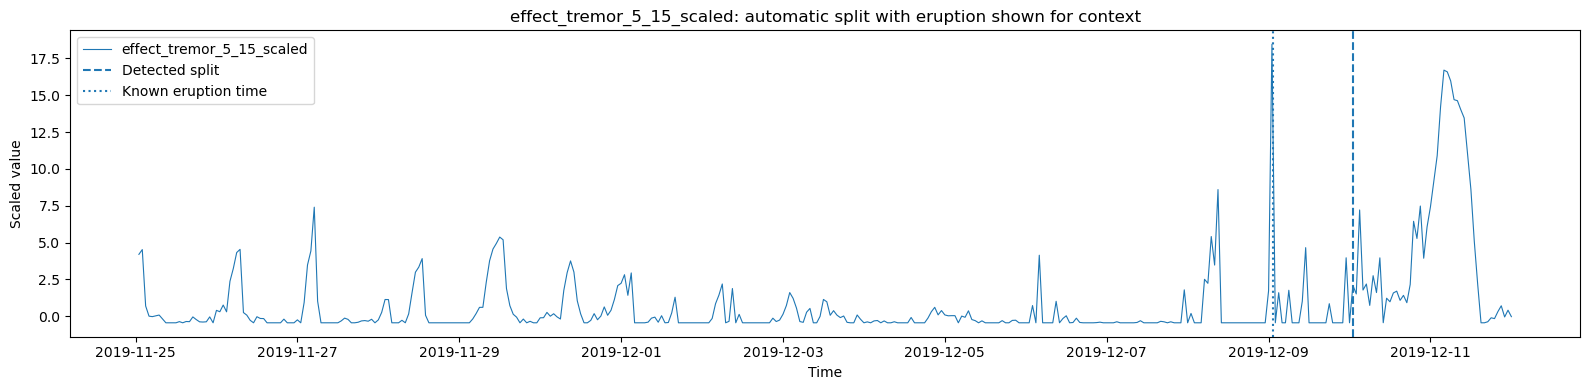

In [5]:
reference_parameters = reference_parameter_table(
    X_model,
    EFFECT,
    max_lags=MAX_LAGS,
    fallback_lag=1,
)
display(reference_parameters)

selected_lag = int(
    reference_parameters.loc[
        reference_parameters["criterion"].eq("AIC"),
        "selected_lag",
    ].iloc[0]
)

workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=EVENT_TIME,
    selected_lag=selected_lag,
    max_lags=MAX_LAGS,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_length=MIN_I2_LENGTH,
    distribution="gaussian",
    pcmci_pc_alpha=0.05,
    pcmci_alpha_level=0.05,
    pcmci_fdr_method="fdr_bh",
    pcmci_cond_ind_test=COND_IND_TEST,
    pcmci_plus_use_contemporaneous_triggers=False,
    run_specs=COMPACT_RUN_SPECS,
)

split_row = split_diagnostics(
    X_mean,
    EFFECT,
    event_time=EVENT_TIME,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)
display(pd.DataFrame([split_row]))

plot_effect_with_split(
    X_mean,
    EFFECT,
    split_row,
    event_time=EVENT_TIME,
)


In [6]:
PRIMARY_RUN_SPECS = (
    {"run": "hmml_primary", "backend": "hmml"},
)

primary_results, primary_comparison, primary_diagnostics = run_suite(
    X_model,
    X_mean,
    workflow,
    run_specs=PRIMARY_RUN_SPECS,
    lag=selected_lag,
)

display(compact_comparison(primary_comparison))
display(compact_diagnostics(primary_diagnostics))


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


,run,backend,lag,split_timestamp,I1_length,I2_length,B2,trigger_candidates,lagged_candidates,contemporaneous_candidates,accepted_triggers,causes,pairs,n_contemporaneous_links,stop_reason
0,hmml_primary,hmml,5,2019-12-10 01:00:00+00:00,360,48,[],[],[],[],[],[],[],0,No lagged non-target B2 variables are available to construct V.


""


## 3. Backend and lag sensitivity

The grid compares HMML, PCMCI, and PCMCI+ across the configured lags. `COMPACT_RUN_SPECS` keeps the optional PCMCI+ extension that tests eligible directed contemporaneous (\(\tau=0\)) links as trigger candidates. This grid is a sensitivity analysis; it does not replace the VAR-AIC primary run.

In [7]:
lag_grid = run_sensitivity_grid(
    X_model,
    X_mean,
    workflow,
    run_specs=COMPACT_RUN_SPECS,
    lags=range(1, workflow.max_lags + 1),
    cond_ind_test=COND_IND_TEST,
)

has_pairs = lag_grid["pairs"].apply(
    lambda value: isinstance(value, list) and len(value) > 0
)
has_tau0_links = lag_grid["n_contemporaneous_links"].fillna(0).gt(0)
error_rows = compact_grid_errors(lag_grid)

print(f"Grid rows: {len(lag_grid)}")
print(f"Rows with accepted pairs: {int(has_pairs.sum())}")
print(f"Rows with PCMCI+ contemporaneous links: {int(has_tau0_links.sum())}")
print(f"Rows with raised exceptions: {len(error_rows)}")

display(compact_sensitivity(lag_grid))
if not error_rows.empty:
    display(error_rows)


c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

Grid rows: 18
Rows with accepted pairs: 1
Rows with PCMCI+ contemporaneous links: 6
Rows with raised exceptions: 0


,run,backend,lag,split_timestamp,B_2,trigger_candidates,T_candidates_lagged,T_candidates_contemporaneous,accepted_triggers,causes,pairs,n_contemporaneous_links,error
0,hmml,hmml,1,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
1,hmml,hmml,2,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
2,hmml,hmml,3,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
3,hmml,hmml,4,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
4,hmml,hmml,5,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
5,hmml,hmml,6,2019-12-10 01:00:00+00:00,"[hydro_2_5_scaled, spectral_log_ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rainfall_mm_scaled]","[hydro_2_5_scaled, spectral_log_ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rainfall_mm_scaled]","[hydro_2_5_scaled, spectral_log_ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled, rainfall_mm_scaled]",[],"[spectral_log_ratio_4p5_8_over_8_16_scaled, event_rate_2_5_scaled]",[hydro_2_5_scaled],"[(hydro_2_5_scaled, spectral_log_ratio_4p5_8_over_8_16_scaled), (hydro_2_5_scaled, event_rate_2_5_scaled)]",0,None
6,pcmci,pcmci,1,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
7,pcmci,pcmci,2,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
8,pcmci,pcmci,3,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
9,pcmci,pcmci,4,2019-12-10 01:00:00+00:00,[],[],[],[],[],[],[],0,None
